In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import StandardScaler
import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
!wget -q https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip

In [5]:
!unzip -q "human+activity+recognition+using+smartphones.zip"

In [6]:
!ls

 human+activity+recognition+using+smartphones.zip  'UCI HAR Dataset.names'
 sample_data					   'UCI HAR Dataset.zip'


In [7]:
!unzip -q "UCI HAR Dataset.zip"

In [8]:
!find "UCI HAR Dataset" -maxdepth 2 -type f

UCI HAR Dataset/train/subject_train.txt
UCI HAR Dataset/train/X_train.txt
UCI HAR Dataset/train/y_train.txt
UCI HAR Dataset/features_info.txt
UCI HAR Dataset/activity_labels.txt
UCI HAR Dataset/features.txt
UCI HAR Dataset/test/subject_test.txt
UCI HAR Dataset/test/X_test.txt
UCI HAR Dataset/test/y_test.txt
UCI HAR Dataset/.DS_Store
UCI HAR Dataset/README.txt


In [9]:
features = pd.read_csv(
    "UCI HAR Dataset/features.txt",
    sep=r"\s+",
    header=None,
    names=["feature_id", "feature_name"]
)

print("Number of features:", len(features))

Number of features: 561


In [10]:
X_train = pd.read_csv(
    "UCI HAR Dataset/train/X_train.txt",
    sep=r"\s+",
    header=None
)

X_train.columns = features["feature_name"]

y_train = pd.read_csv(
    "UCI HAR Dataset/train/y_train.txt",
    header=None,
    names=["Activity"]
)

X_test = pd.read_csv(
    "UCI HAR Dataset/test/X_test.txt",
    sep=r"\s+",
    header=None
)

X_test.columns = features["feature_name"]

y_test = pd.read_csv(
    "UCI HAR Dataset/test/y_test.txt",
    header=None,
    names=["Activity"]
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7352, 561)
y_train: (7352, 1)
X_test: (2947, 561)
y_test: (2947, 1)


In [11]:
activity_labels = pd.read_csv(
    "UCI HAR Dataset/activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["Activity_ID", "Activity_Name"]
)

activity_labels

,Activity_ID,Activity_Name
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


In [12]:
activity_mapping = dict(
    zip(
        activity_labels["Activity_ID"],
        activity_labels["Activity_Name"]
    )
)

print(activity_mapping)

{1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}


In [13]:
y_train["Activity_Name"] = y_train["Activity"].map(activity_mapping)

y_train["Activity_Name"].value_counts()

,count
Activity_Name,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


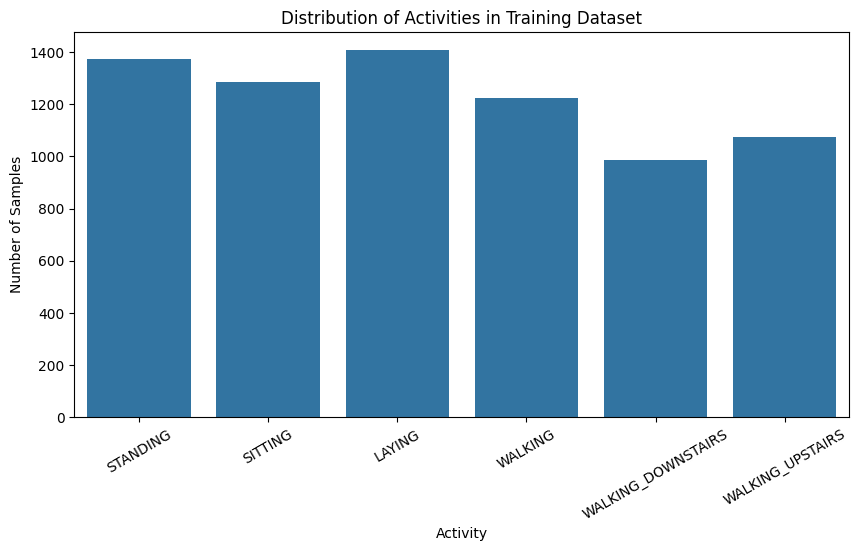

In [14]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=y_train,
    x="Activity_Name"
)

plt.title("Distribution of Activities in Training Dataset")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)

plt.show()

In [15]:
print("Missing values in X_train:",
      X_train.isnull().sum().sum())

print("Missing values in X_test:",
      X_test.isnull().sum().sum())

print("Missing values in y_train:",
      y_train["Activity"].isnull().sum())

print("Missing values in y_test:",
      y_test["Activity"].isnull().sum())

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0


In [16]:
X_train.head()

feature_name,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [17]:
X_train.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
feature_name,,,,,,,,
tBodyAcc-mean()-X,7352.0,0.274488,0.070261,-1.000000,0.262975,0.277193,0.288461,1.000000
tBodyAcc-mean()-Y,7352.0,-0.017695,0.040811,-1.000000,-0.024863,-0.017219,-0.010783,1.000000
tBodyAcc-mean()-Z,7352.0,-0.109141,0.056635,-1.000000,-0.120993,-0.108676,-0.097794,1.000000
tBodyAcc-std()-X,7352.0,-0.605438,0.448734,-1.000000,-0.992754,-0.946196,-0.242813,1.000000
tBodyAcc-std()-Y,7352.0,-0.510938,0.502645,-0.999873,-0.978129,-0.851897,-0.034231,0.916238
tBodyAcc-std()-Z,7352.0,-0.604754,0.418687,-1.000000,-0.980233,-0.859365,-0.262415,1.000000
tBodyAcc-mad()-X,7352.0,-0.630512,0.424073,-1.000000,-0.993591,-0.950709,-0.292680,1.000000
tBodyAcc-mad()-Y,7352.0,-0.526907,0.485942,-1.000000,-0.978162,-0.857328,-0.066701,0.967664
tBodyAcc-mad()-Z,7352.0,-0.606150,0.414122,-1.000000,-0.980251,-0.857143,-0.265671,1.000000


In [18]:
# Keep only the original target column
y_train_final = y_train["Activity"].copy()
y_test_final = y_test["Activity"].copy()

print("Training target shape:", y_train_final.shape)
print("Testing target shape:", y_test_final.shape)

print("\nTraining classes:")
print(sorted(y_train_final.unique()))

print("\nTesting classes:")
print(sorted(y_test_final.unique()))

Training target shape: (7352,)
Testing target shape: (2947,)

Training classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Testing classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [19]:
y_train_names = y_train_final.map(activity_mapping)
y_test_names = y_test_final.map(activity_mapping)

print(y_train_names.head())

0    STANDING
1    STANDING
2    STANDING
3    STANDING
4    STANDING
Name: Activity, dtype: object


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (7352, 561)
Scaled testing data shape: (2947, 561)


In [21]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

print("Five models created successfully.")

Five models created successfully.


In [22]:
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train_final)
    else:
        model.fit(X_train, y_train_final)

    trained_models[name] = model

    print(f"{name} completed.\n")

Training Logistic Regression...
Logistic Regression completed.

Training Decision Tree...
Decision Tree completed.

Training KNN...
KNN completed.

Training Naive Bayes...
Naive Bayes completed.

Training Random Forest...
Random Forest completed.



In [23]:
predictions = {}

for name, model in trained_models.items():

    if name in ["Logistic Regression", "KNN"]:
        X_eval = X_test_scaled
    else:
        X_eval = X_test

    predictions[name] = model.predict(X_eval)

    print(f"{name}: predictions generated")

Logistic Regression: predictions generated
Decision Tree: predictions generated
KNN: predictions generated
Naive Bayes: predictions generated
Random Forest: predictions generated


In [24]:
results = []

for name, model in trained_models.items():

    if name in ["Logistic Regression", "KNN"]:
        X_eval = X_test_scaled
    else:
        X_eval = X_test

    y_pred = predictions[name]

    # Probability predictions needed for multiclass AUC
    y_prob = model.predict_proba(X_eval)

    accuracy = accuracy_score(
        y_test_final,
        y_pred
    )

    auc = roc_auc_score(
        y_test_final,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    precision = precision_score(
        y_test_final,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test_final,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test_final,
        y_pred,
        average="weighted"
    )

    mcc = matthews_corrcoef(
        y_test_final,
        y_pred
    )

    results.append({
        "ML Model Name": name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    })

print("All six metrics calculated successfully.")

All six metrics calculated successfully.


In [25]:
results_df = pd.DataFrame(results)

results_df

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.954869,0.997485,0.956650,0.954869,0.954809,0.946140
1,Decision Tree,0.862233,0.917281,0.863273,0.862233,0.861652,0.834813
2,KNN,0.880217,0.976437,0.888331,0.880217,0.879025,0.857806
3,Naive Bayes,0.770275,0.958338,0.794683,0.770275,0.768770,0.728609
4,Random Forest,0.925687,0.995320,0.927035,0.925687,0.925594,0.910933


In [26]:
comparison_table = results_df.copy()

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

comparison_table[metric_columns] = (
    comparison_table[metric_columns].round(4)
)

comparison_table

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9549,0.9975,0.9567,0.9549,0.9548,0.9461
1,Decision Tree,0.8622,0.9173,0.8633,0.8622,0.8617,0.8348
2,KNN,0.8802,0.9764,0.8883,0.8802,0.8790,0.8578
3,Naive Bayes,0.7703,0.9583,0.7947,0.7703,0.7688,0.7286
4,Random Forest,0.9257,0.9953,0.9270,0.9257,0.9256,0.9109


In [27]:
winner = results_df.loc[
    results_df["F1"].idxmax()
]

print("Overall Winner:", winner["ML Model Name"])
print("\nWinner's Performance:")
print(
    winner[
        [
            "Accuracy",
            "AUC",
            "Precision",
            "Recall",
            "F1",
            "MCC"
        ]
    ].round(4)
)

Overall Winner: Logistic Regression

Winner's Performance:
Accuracy     0.954869
AUC          0.997485
Precision     0.95665
Recall       0.954869
F1           0.954809
MCC           0.94614
Name: 0, dtype: object


# **Model observations**
# Logistic Regression

Logistic Regression achieved the best overall performance among the five models. It obtained an accuracy of 95.49% and an AUC of 99.75%, indicating strong classification performance and excellent class separability. Its Precision, Recall and F1 scores are also consistently high, while the MCC of 0.9461 indicates a strong correlation between predicted and actual classes.

Conclusion: Logistic Regression is the best-performing model for this dataset.

# Decision Tree

The Decision Tree achieved an accuracy of 86.22%, with an AUC of 91.73%. Its F1 score was 86.17% and MCC was 0.8348. Although it provides reasonable classification performance, it performed substantially below Logistic Regression and Random Forest.

Conclusion: Decision Tree provides moderate performance but is not the strongest model for this dataset.

# KNN

KNN achieved an accuracy of 88.02% and an AUC of 97.64%. Its Precision was 88.83%, Recall was 88.02%, and F1 was 87.90%. Its MCC of 0.8578 indicates good agreement between predicted and actual classifications.

Conclusion: KNN performs reasonably well, but its overall performance is lower than Logistic Regression and Random Forest.

# Naive Bayes

Naive Bayes produced the lowest overall performance among the five models. It achieved an accuracy of 77.03%, F1 score of 76.88%, and MCC of 0.7286. Although its AUC of 95.83% is relatively high, its classification accuracy and other metrics are considerably lower than the other models.

Conclusion: Naive Bayes is the weakest-performing model for this dataset based on the obtained results.

# Random Forest

Random Forest achieved the second-best overall performance, with an accuracy of 92.57%, AUC of 99.53%, Precision of 92.70%, Recall of 92.57%, F1 of 92.56%, and MCC of 0.9109.

Its AUC is very close to Logistic Regression's AUC, showing excellent discrimination, but its other evaluation metrics remain below Logistic Regression.

Conclusion: Random Forest is a strong model, but Logistic Regression performs better on this dataset.

# **Overall Winner: Logistic Regression**

Logistic Regression achieved the best overall performance among all five evaluated classification models. It obtained the highest Accuracy (95.49%), AUC (99.75%), Precision (95.67%), Recall (95.49%), F1 Score (95.48%), and MCC (0.9461). Random Forest was the second-best performing model, while Naive Bayes achieved the lowest overall performance. Therefore, Logistic Regression was selected as the overall best model for the Human Activity Recognition classification task.

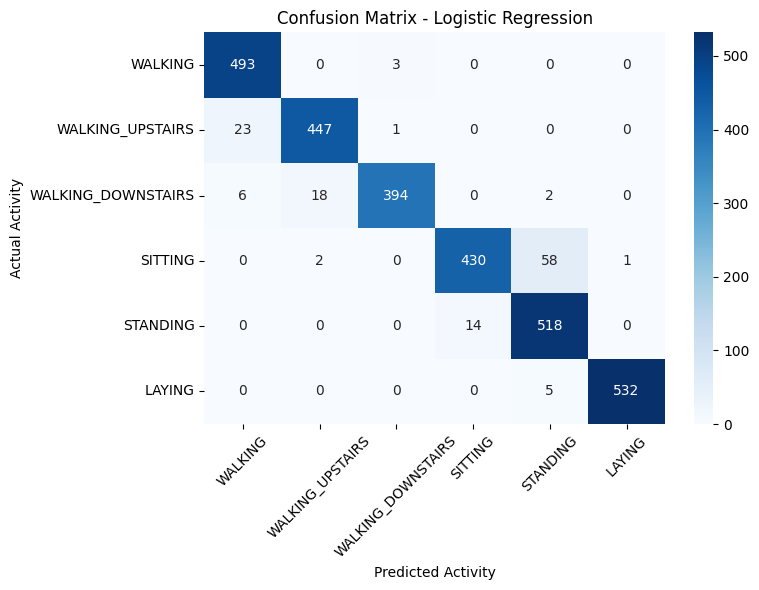

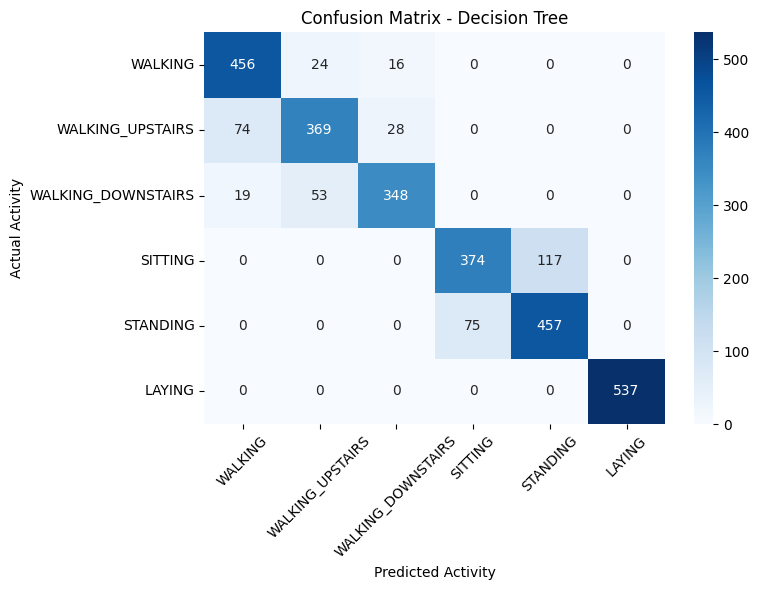

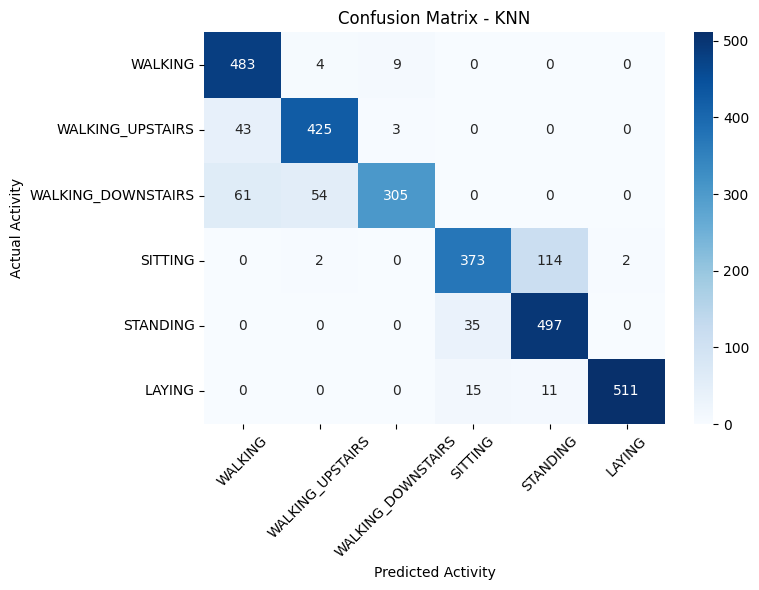

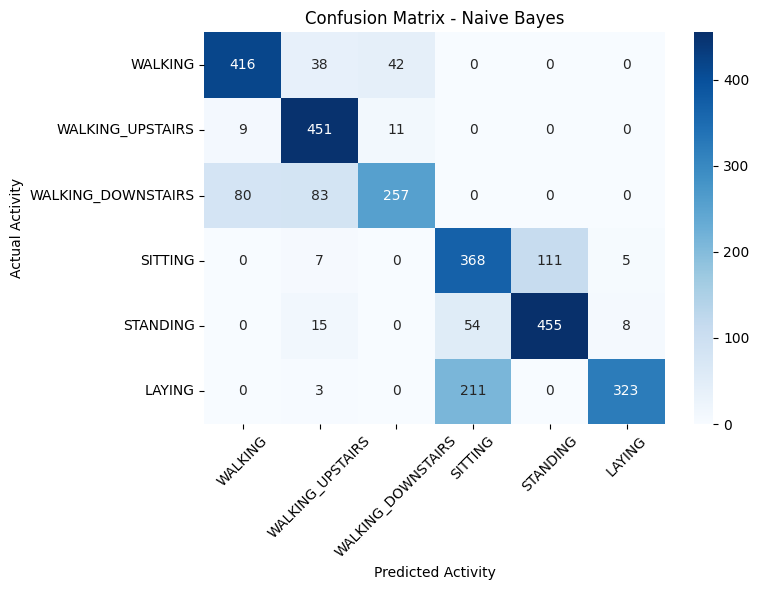

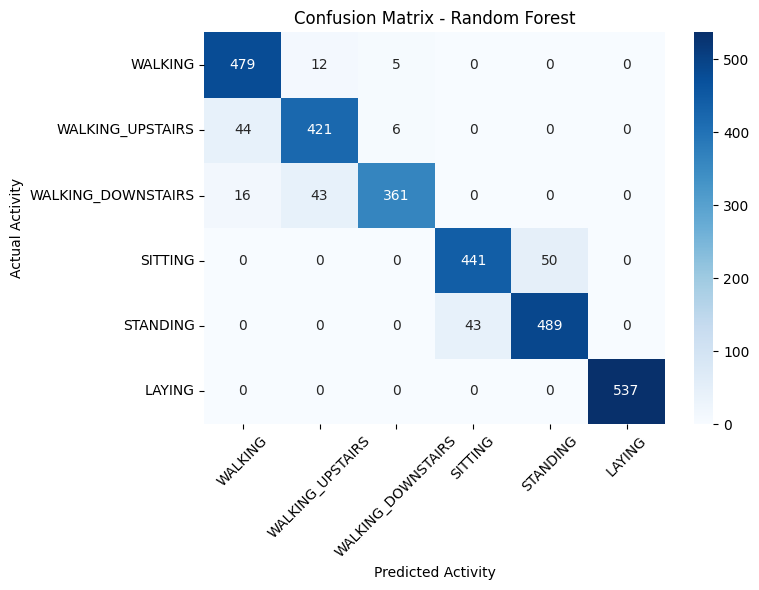

In [28]:
class_names = [
    activity_mapping[i]
    for i in sorted(activity_mapping.keys())
]

for name in trained_models:

    cm = confusion_matrix(
        y_test_final,
        predictions[name]
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Activity")
    plt.ylabel("Actual Activity")

    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [29]:
for name in trained_models:

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test_final,
            predictions[name],
            target_names=class_names
        )
    )



Logistic Regression
                    precision    recall  f1-score   support

           WALKING       0.94      0.99      0.97       496
  WALKING_UPSTAIRS       0.96      0.95      0.95       471
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
           SITTING       0.97      0.88      0.92       491
          STANDING       0.89      0.97      0.93       532
            LAYING       1.00      0.99      0.99       537

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947



Decision Tree
                    precision    recall  f1-score   support

           WALKING       0.83      0.92      0.87       496
  WALKING_UPSTAIRS       0.83      0.78      0.80       471
WALKING_DOWNSTAIRS       0.89      0.83      0.86       420
           SITTING       0.83      0.76      0.80       491
          STANDING       0.80      0.86      0.83       53

In [30]:
comparison_table.to_csv(
    "model_comparison.csv",
    index=False
)

print("model_comparison.csv created successfully.")

model_comparison.csv created successfully.


In [31]:
comparison_table

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9549,0.9975,0.9567,0.9549,0.9548,0.9461
1,Decision Tree,0.8622,0.9173,0.8633,0.8622,0.8617,0.8348
2,KNN,0.8802,0.9764,0.8883,0.8802,0.8790,0.8578
3,Naive Bayes,0.7703,0.9583,0.7947,0.7703,0.7688,0.7286
4,Random Forest,0.9257,0.9953,0.9270,0.9257,0.9256,0.9109


In [32]:
test_data = X_test.copy()

test_data["Activity"] = y_test_final.values

test_data["Activity_Name"] = y_test_final.map(
    activity_mapping
).values

print("Test data shape:", test_data.shape)

test_data.head()

Test data shape: (2947, 563)


feature_name,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity,Activity_Name
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,5,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,5,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,5,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,5,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,5,STANDING


In [33]:
test_data.to_csv(
    "test_data.csv",
    index=False
)

print("test_data.csv created successfully.")

test_data.csv created successfully.


In [34]:
import os
import joblib

os.makedirs("models", exist_ok=True)

In [35]:
joblib.dump(
    trained_models["Logistic Regression"],
    "models/logistic_regression.pkl"
)

joblib.dump(
    trained_models["Decision Tree"],
    "models/decision_tree.pkl"
)

joblib.dump(
    trained_models["KNN"],
    "models/knn.pkl"
)

joblib.dump(
    trained_models["Naive Bayes"],
    "models/naive_bayes.pkl"
)

joblib.dump(
    trained_models["Random Forest"],
    "models/random_forest.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

joblib.dump(
    activity_mapping,
    "models/activity_mapping.pkl"
)

print("All model files saved successfully.")

All model files saved successfully.


In [36]:
!find models -type f

models/scaler.pkl
models/logistic_regression.pkl
models/random_forest.pkl
models/naive_bayes.pkl
models/decision_tree.pkl
models/activity_mapping.pkl
models/knn.pkl


In [37]:
!zip -r models.zip models

  adding: models/ (stored 0%)
  adding: models/scaler.pkl (deflated 43%)
  adding: models/logistic_regression.pkl (deflated 8%)
  adding: models/random_forest.pkl (deflated 80%)
  adding: models/naive_bayes.pkl (deflated 22%)
  adding: models/decision_tree.pkl (deflated 80%)
  adding: models/activity_mapping.pkl (deflated 27%)
  adding: models/knn.pkl (deflated 11%)


In [38]:
from google.colab import files

files.download("test_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
files.download("model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
files.download("models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>